<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/Zadanie_baza_film%C3%B3w.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza bazy filmów TMDB

W tym notatniku przeanalizujemy dane filmów z serwisu TMDB. Wykonamy następujące zadania:

1. Znajdziemy 10 najwyżej ocenianych filmów, których liczba głosów przekracza trzeci kwartyl rozkładu vote_count.
2. Obliczymy średni przychód i średni budżet w latach 2010–2016, a następnie przedstawimy je na wykresie (słupkowy dla przychodu, liniowy dla budżetu).
3. Połączymy bazę filmów z bazą gatunków, aby znaleźć najczęściej występujący gatunek.
4. Określimy, który gatunek ma najdłuższy średni czas trwania.
5. Dla tego gatunku narysujemy histogram czasu trwania filmów.

In [ ]:
from google.colab import files
uploaded = files.upload()
print("Przesłane pliki:", list(uploaded.keys()))

Saving tmdb_genres.csv to tmdb_genres.csv
Saving tmdb_movies.csv to tmdb_movies.csv
Przesłane pliki: ['tmdb_genres.csv', 'tmdb_movies.csv']


📥 Krok 1: Import bibliotek i wczytanie danych

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

In [ ]:
# Wyświetlmy nazwy przesłanych plików, żeby upewnić się, jakie są
print("Przesłane pliki:", list(uploaded.keys()))

Teraz wczytamy je do osobnych DataFrame:

In [ ]:
# Wczytaj plik z gatunkami (pierwszy klucz)
genres_data = uploaded['tmdb_genres.csv']
genres = pd.read_csv(io.BytesIO(genres_data), index_col=0)

# Wczytaj plik z filmami (drugi klucz)
movies_data = uploaded['tmdb_movies.csv']
movies = pd.read_csv(io.BytesIO(movies_data), index_col=0)

print("✅ Dane wczytane pomyślnie.")
print(f"Filmy: {movies.shape}, Gatunki: {genres.shape}")

✅ Dane wczytane pomyślnie.
Filmy: (4803, 16), Gatunki: (21, 1)


🎯 Krok 2: Zadanie 1 – 10 najwyżej ocenianych filmów (vote_average) z vote_count > Q3

In [ ]:
# Obliczamy trzeci kwartyl liczby głosów
q3 = movies['vote_count'].quantile(0.75)
print(f"Trzeci kwartyl vote_count: {q3:.2f}")

# Filtrujemy filmy z liczbą głosów powyżej Q3
popular_movies = movies[movies['vote_count'] > q3].copy()

# Sortujemy malejąco po średniej ocenie i bierzemy 10 pierwszych
top10 = popular_movies.sort_values('vote_average', ascending=False).head(10)

# Wyświetlamy tylko interesujące kolumny
print("\n=== 10 NAJWYŻEJ OCENIANYCH FILMÓW (vote_count > Q3) ===")
print(top10[['title', 'vote_average', 'vote_count']].to_string(index=False))

Trzeci kwartyl vote_count: 737.00

=== 10 NAJWYŻEJ OCENIANYCH FILMÓW (vote_count > Q3) ===
                          title  vote_average  vote_count
       The Shawshank Redemption           8.5        8205
                  The Godfather           8.4        5893
         The Godfather: Part II           8.3        3338
                   Pulp Fiction           8.3        8428
                       Whiplash           8.3        4254
               Schindler's List           8.3        4329
                     Fight Club           8.3        9413
                  Spirited Away           8.3        3840
                         Psycho           8.2        2320
One Flew Over the Cuckoo's Nest           8.2        2919


 Przygotowanie danych i diagnostyka

In [ ]:
# Konwersja daty na rok
movies['release_year'] = pd.to_datetime(movies['release_date'], errors='coerce').dt.year

# Filtrujemy lata 2010–2016
df = movies[(movies['release_year'] >= 2010) & (movies['release_year'] <= 2016)].copy()

# Diagnostyka (możesz pominąć, ale pokazuje problem)
print("📊 Liczba filmów w latach 2010–2016:")
print(df['release_year'].value_counts().sort_index())
print("\n💰 Statystyki budżetu (z zerami):")
print(df.groupby('release_year')['budget'].describe())
print("\n🟡 Filmy z budżetem = 0:")
print(df[df['budget'] == 0].groupby('release_year').size())

📊 Liczba filmów w latach 2010–2016:
release_year
2010.0    225
2011.0    223
2012.0    208
2013.0    231
2014.0    238
2015.0    216
2016.0    104
Name: count, dtype: int64

💰 Statystyki budżetu (z zerami):
              count          mean           std  min         25%         50%  \
release_year                                                                   
2010.0        225.0  3.449541e+07  4.784234e+07  0.0  2000000.00  15000000.0   
2011.0        223.0  3.477232e+07  4.807767e+07  0.0  3250000.00  19100000.0   
2012.0        208.0  3.492203e+07  5.409506e+07  0.0   193750.00  13500000.0   
2013.0        231.0  3.552329e+07  5.256074e+07  0.0  1000000.00  15000000.0   
2014.0        238.0  3.095989e+07  4.852086e+07  0.0        0.00  11000000.0   
2015.0        216.0  3.113216e+07  4.895400e+07  0.0        0.75  10000000.0   
2016.0        104.0  4.570327e+07  6.009587e+07  0.0  4975000.00  20000000.0   

                     75%          max  
release_year                    

Usunięcie filmów z budżetem 0

In [ ]:
# Zostawiamy tylko filmy z budżetem > 0 (brak danych oznaczony jako 0)
df_positive = df[df['budget'] > 0].copy()

print("📊 Liczba filmów z budżetem > 0 w latach 2010–2016:")
print(df_positive['release_year'].value_counts().sort_index())

📊 Liczba filmów z budżetem > 0 w latach 2010–2016:
release_year
2010.0    185
2011.0    195
2012.0    159
2013.0    185
2014.0    170
2015.0    162
2016.0     86
Name: count, dtype: int64


 Obliczenie średnich rocznych

In [ ]:
yearly_stats = df_positive.groupby('release_year').agg({
    'revenue': 'mean',
    'budget': 'mean'
}).reset_index()

print("\n💰 Średnie (po odrzuceniu filmów z budget = 0):")
print(yearly_stats)


💰 Średnie (po odrzuceniu filmów z budget = 0):
   release_year       revenue        budget
0        2010.0  1.095040e+08  4.195388e+07
1        2011.0  1.049295e+08  3.976527e+07
2        2012.0  1.495248e+08  4.568417e+07
3        2013.0  1.251115e+08  4.435611e+07
4        2014.0  1.414543e+08  4.334384e+07
5        2015.0  1.387490e+08  4.150955e+07
6        2016.0  1.680375e+08  5.526907e+07


📊 Krok 3: Zadanie 2 – Średni przychód i budżet w latach 2010–2016

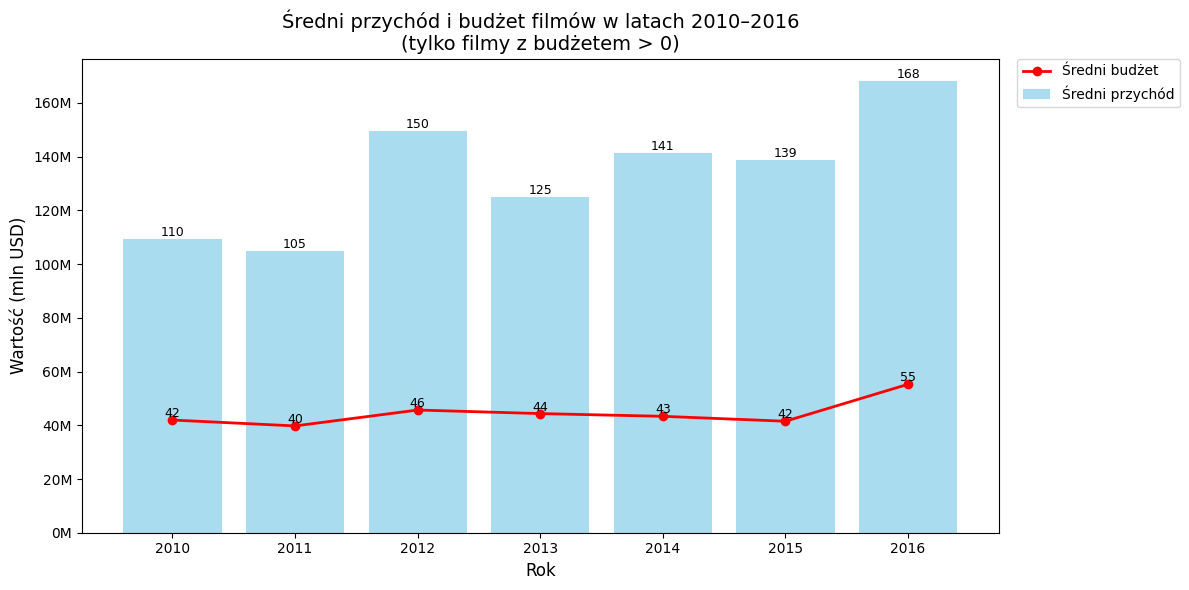

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Używamy danych po odrzuceniu filmów z budżetem 0 (df_positive już istnieje)
yearly_stats = df_positive.groupby('release_year').agg({
    'revenue': 'mean',
    'budget': 'mean'
}).reset_index()

# Przelicz na miliony
yearly_stats['revenue_mln'] = yearly_stats['revenue'] / 1_000_000
yearly_stats['budget_mln'] = yearly_stats['budget'] / 1_000_000

# Funkcja do formatowania osi Y w milionach
def millions(x, pos):
    return f'{x:.0f}M'

# Tworzenie wykresu
fig, ax = plt.subplots(figsize=(12, 6))

# Słupki dla przychodu
bars = ax.bar(yearly_stats['release_year'], yearly_stats['revenue_mln'],
              color='skyblue', alpha=0.7, label='Średni przychód')

# Linia dla budżetu
ax.plot(yearly_stats['release_year'], yearly_stats['budget_mln'],
        color='red', marker='o', linewidth=2, label='Średni budżet')

# Formatowanie osi Y
ax.yaxis.set_major_formatter(FuncFormatter(millions))
ax.set_ylabel('Wartość (mln USD)', fontsize=12)
ax.set_xlabel('Rok', fontsize=12)
ax.set_title('Średni przychód i budżet filmów w latach 2010–2016\n(tylko filmy z budżetem > 0)', fontsize=14)
ax.set_xticks(yearly_stats['release_year'])
ax.set_xticklabels(yearly_stats['release_year'].astype(int))

# Dodanie etykiet z wartościami (opcjonalnie, ale zwiększa czytelność)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}', ha='center', va='bottom', fontsize=9)

for i, (x, y) in enumerate(zip(yearly_stats['release_year'], yearly_stats['budget_mln'])):
    ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', fontsize=9)

# Legenda poza obszarem wykresu
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

plt.tight_layout()
plt.show()

🔗 Krok 4: Połączenie tabeli filmów z tabelą gatunków

In [ ]:
# Łączymy na podstawie kolumny 'genre_id' w movies i indeksu w genres
movies_genres = movies.merge(genres, left_on='genre_id', right_index=True, how='left')

# Sprawdźmy, czy połączenie się udało
print("Połączone dane – pierwsze wiersze:")
print(movies_genres[['title', 'genres', 'genre_id']].head())

Połączone dane – pierwsze wiersze:
                                      title     genres  genre_id
0                                    Avatar     Action      28.0
1  Pirates of the Caribbean: At World's End  Adventure      12.0
2                                   Spectre     Action      28.0
3                     The Dark Knight Rises     Action      28.0
4                               John Carter     Action      28.0


🏆 Krok 5: Najczęściej występujący gatunek

In [ ]:
# Liczymy wystąpienia każdego gatunku
genre_counts = movies_genres['genres'].value_counts()
most_common_genre = genre_counts.idxmax()
most_common_count = genre_counts.max()

print(f"\n=== NAJCZĘSTSZY GATUNEK ===")
print(f"{most_common_genre}: {most_common_count} filmów")


=== NAJCZĘSTSZY GATUNEK ===
Drama: 1207 filmów


⏱️ Krok 6: Gatunek o najdłuższym średnim czasie trwania

In [ ]:
# Grupujemy po gatunku i obliczamy średni czas trwania (pomijamy braki)
runtime_by_genre = movies_genres.groupby('genres')['runtime'].mean().sort_values(ascending=False)
longest_genre = runtime_by_genre.idxmax()
longest_runtime = runtime_by_genre.max()

print(f"\n=== GATUNEK O NAJDUŻSZYM ŚREDNIM CZASIE TRWANIA ===")
print(f"{longest_genre}: średnio {longest_runtime:.1f} minut")


=== GATUNEK O NAJDUŻSZYM ŚREDNIM CZASIE TRWANIA ===
History: średnio 134.0 minut


📈 Krok 7: Histogram czasu trwania dla tego gatunku

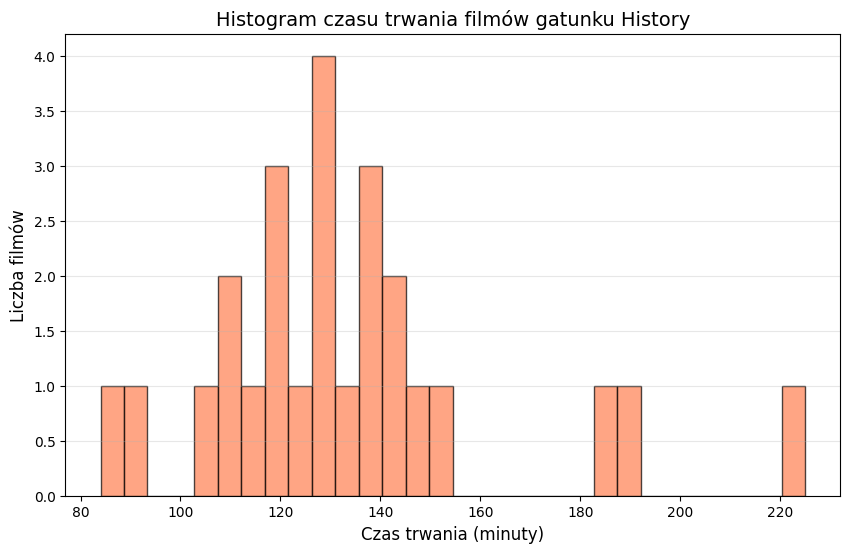

In [ ]:
# Wybieramy filmy należące do tego gatunku
longest_genre_movies = movies_genres[movies_genres['genres'] == longest_genre]

# Usuwamy ewentualne braki w czasie trwania
runtimes = longest_genre_movies['runtime'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(runtimes, bins=30, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Czas trwania (minuty)', fontsize=12)
plt.ylabel('Liczba filmów', fontsize=12)
plt.title(f'Histogram czasu trwania filmów gatunku {longest_genre}', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

💾 (Opcjonalnie) Zapisanie wyników do plików CSV

In [ ]:
# Zapisz top10 do pliku
top10.to_csv('top10_movies.csv', index=False)

# Zapisz zestawienie roczne
yearly_stats.to_csv('yearly_stats_2010_2016.csv', index=False)

# Zapisz statystyki gatunków
genre_stats = movies_genres.groupby('genres').agg({
    'runtime': 'mean',
    'genre_id': 'count'
}).rename(columns={'genre_id': 'count', 'runtime': 'avg_runtime'})
genre_stats.to_csv('genre_statistics.csv')

📝 Podsumowanie
Otrzymaliśmy:

Listę 10 filmów z najwyższą średnią oceną, które mają liczbę głosów powyżej 3. kwartyla.

Wykres porównujący średni przychód i budżet w latach 2010–2016.

Nazwę najpopularniejszego gatunku oraz liczbę filmów.

Gatunek o najdłuższym średnim czasie trwania i histogram rozkładu czasu trwania dla tego gatunku.